In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("C:/Users/HP/Downloads/all_conditions.csv")
print(df.head())


   Stn Id    Stn Name        CIMIS Region      Date  ETo (in)  Precip (in)  \
0       2  FivePoints  San Joaquin Valley  1/1/2018      0.06         0.00   
1       2  FivePoints  San Joaquin Valley  1/2/2018      0.04         0.00   
2       2  FivePoints  San Joaquin Valley  1/3/2018      0.04         0.00   
3       2  FivePoints  San Joaquin Valley  1/4/2018      0.07         0.01   
4       2  FivePoints  San Joaquin Valley  1/5/2018      0.07         0.00   

   Sol Rad (Ly/day)  Avg Vap Pres (mBars)  Max Air Temp (F)  Min Air Temp (F)  \
0             219.0                   7.3              63.4              35.3   
1             127.0                   7.4              59.8              37.7   
2             125.0                   8.4              61.1              37.3   
3             219.0                  11.6              69.2              48.7   
4             239.0                  12.7              73.8              47.5   

   Avg Air Temp (F)  Max Rel Hum (%)  Min Re

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128125 entries, 0 to 128124
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Stn Id                128125 non-null  int64  
 1   Stn Name              128125 non-null  object 
 2   CIMIS Region          128125 non-null  object 
 3   Date                  128125 non-null  object 
 4   ETo (in)              128042 non-null  float64
 5   Precip (in)           128125 non-null  float64
 6   Sol Rad (Ly/day)      128125 non-null  float64
 7   Avg Vap Pres (mBars)  128125 non-null  float64
 8   Max Air Temp (F)      128122 non-null  float64
 9   Min Air Temp (F)      128124 non-null  float64
 10  Avg Air Temp (F)      128120 non-null  float64
 11  Max Rel Hum (%)       128125 non-null  float64
 12  Min Rel Hum (%)       128125 non-null  float64
 13  Avg Rel Hum (%)       128112 non-null  float64
 14  Dew Point (F)         128112 non-null  float64
 15  

In [3]:
print(df['CIMIS Region'].unique())

['San Joaquin Valley' 'Sacramento Valley' 'Sierra Foothill' 'Bishop'
 'Imperial/Coachella Valley' 'Northeast Plateau' 'Los Angeles Basin'
 'San Francisco Bay' 'Central Coast Valleys' 'South Coast Valleys'
 'North Coast Valleys' 'Monterey Bay' 'San Bernardino'
 'Eastern Sierra Basin & Range']


In [4]:
df.isnull().sum()

Stn Id                   0
Stn Name                 0
CIMIS Region             0
Date                     0
ETo (in)                83
Precip (in)              0
Sol Rad (Ly/day)         0
Avg Vap Pres (mBars)     0
Max Air Temp (F)         3
Min Air Temp (F)         1
Avg Air Temp (F)         5
Max Rel Hum (%)          0
Min Rel Hum (%)          0
Avg Rel Hum (%)         13
Dew Point (F)           13
Avg Wind Speed (mph)     0
Wind Run (miles)         0
Avg Soil Temp (F)       20
Target                   0
dtype: int64

In [5]:
# 2. TEMPORAL FEATURE ENGINEERING
# Converting date to extract seasonal cycles (Fire risk is highly seasonal)
df['Date'] = pd.to_datetime(df["Date"], format="%m/%d/%Y", errors="coerce")
df['Month'] = df['Date'].dt.month
df['DayOfYear'] = df['Date'].dt.dayofyear

# Cyclic encoding for Day of Year (helps the model understand Dec 31 is near Jan 1)
df['day_sin'] = np.sin(2 * np.pi * df['DayOfYear'] / 365)
df['day_cos'] = np.cos(2 * np.pi * df['DayOfYear'] / 365)

In [6]:
cols_to_fill = ['ETo (in)', 'Max Air Temp (F)', 'Min Air Temp (F)', 
                'Avg Air Temp (F)', 'Avg Rel Hum (%)', 'Dew Point (F)', 'Avg Soil Temp (F)']

for col in cols_to_fill:
    # Fill based on Regional-Monthly Median
    df[col] = df.groupby(['CIMIS Region', 'Month'])[col].transform(lambda x: x.fillna(x.median()))
    # Final safety fill for any unique combinations with no data
    df[col] = df[col].fillna(df[col].median())

print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
Stn Id                  0
Stn Name                0
CIMIS Region            0
Date                    0
ETo (in)                0
Precip (in)             0
Sol Rad (Ly/day)        0
Avg Vap Pres (mBars)    0
Max Air Temp (F)        0
Min Air Temp (F)        0
Avg Air Temp (F)        0
Max Rel Hum (%)         0
Min Rel Hum (%)         0
Avg Rel Hum (%)         0
Dew Point (F)           0
Avg Wind Speed (mph)    0
Wind Run (miles)        0
Avg Soil Temp (F)       0
Target                  0
Month                   0
DayOfYear               0
day_sin                 0
day_cos                 0
dtype: int64


In [7]:
# Wind–Temperature Interaction
df["wind_temp_ratio"] = df["Avg Wind Speed (mph)"] / (df["Avg Air Temp (F)"] + 1)

for col in ['Max Air Temp (F)', 'Min Rel Hum (%)', 'Avg Wind Speed (mph)']:
    df[f'{col}_lag1'] = df.groupby('Stn Id')[col].shift(1)
    df[f'{col}_lag3_mean'] = df.groupby('Stn Id')[col].transform(lambda x: x.rolling(3).mean())

# Fill the new NaNs created by lagging with the current day's value
df = df.fillna(method='bfill')

# 5. DERIVED WEATHER INDICES
# High temp + Low humidity = High risk. This ratio captures "Evaporative Demand."
df['Dryness_Index'] = df['Max Air Temp (F)'] / (df['Min Rel Hum (%)'] + 1)


In [8]:
from sklearn.preprocessing import LabelEncoder
#print(df.isnull().sum())
#df = df.dropna()
df = df.drop(columns=["Date", "Stn Name", "Stn Id"], errors='ignore')
print(df.columns)
le_region = LabelEncoder()
df['CIMIS Region'] = le_region.fit_transform(df['CIMIS Region'])

Index(['CIMIS Region', 'ETo (in)', 'Precip (in)', 'Sol Rad (Ly/day)',
       'Avg Vap Pres (mBars)', 'Max Air Temp (F)', 'Min Air Temp (F)',
       'Avg Air Temp (F)', 'Max Rel Hum (%)', 'Min Rel Hum (%)',
       'Avg Rel Hum (%)', 'Dew Point (F)', 'Avg Wind Speed (mph)',
       'Wind Run (miles)', 'Avg Soil Temp (F)', 'Target', 'Month', 'DayOfYear',
       'day_sin', 'day_cos', 'wind_temp_ratio', 'Max Air Temp (F)_lag1',
       'Max Air Temp (F)_lag3_mean', 'Min Rel Hum (%)_lag1',
       'Min Rel Hum (%)_lag3_mean', 'Avg Wind Speed (mph)_lag1',
       'Avg Wind Speed (mph)_lag3_mean', 'Dryness_Index'],
      dtype='object')


In [9]:
print(df.head(2))

   CIMIS Region  ETo (in)  Precip (in)  Sol Rad (Ly/day)  \
0            11      0.06          0.0             219.0   
1            11      0.04          0.0             127.0   

   Avg Vap Pres (mBars)  Max Air Temp (F)  Min Air Temp (F)  Avg Air Temp (F)  \
0                   7.3              63.4              35.3              47.8   
1                   7.4              59.8              37.7              47.2   

   Max Rel Hum (%)  Min Rel Hum (%)  ...   day_sin   day_cos  wind_temp_ratio  \
0             82.0             46.0  ...  0.017213  0.999852         0.067623   
1             80.0             52.0  ...  0.034422  0.999407         0.064315   

   Max Air Temp (F)_lag1  Max Air Temp (F)_lag3_mean  Min Rel Hum (%)_lag1  \
0                   63.4                   61.433333                  46.0   
1                   63.4                   61.433333                  46.0   

   Min Rel Hum (%)_lag3_mean  Avg Wind Speed (mph)_lag1  \
0                       49.0         

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128125 entries, 0 to 128124
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   CIMIS Region                    128125 non-null  int32  
 1   ETo (in)                        128125 non-null  float64
 2   Precip (in)                     128125 non-null  float64
 3   Sol Rad (Ly/day)                128125 non-null  float64
 4   Avg Vap Pres (mBars)            128125 non-null  float64
 5   Max Air Temp (F)                128125 non-null  float64
 6   Min Air Temp (F)                128125 non-null  float64
 7   Avg Air Temp (F)                128125 non-null  float64
 8   Max Rel Hum (%)                 128125 non-null  float64
 9   Min Rel Hum (%)                 128125 non-null  float64
 10  Avg Rel Hum (%)                 128125 non-null  float64
 11  Dew Point (F)                   128125 non-null  float64
 12  Avg Wind Speed (

In [11]:

X = df.drop(columns=["Target"])
y = df["Target"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42,stratify=y
)

In [13]:
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (102500, 27) (102500,)
Test : (25625, 27) (25625,)


In [14]:
scale_factor = (y_train == 0).sum() / (y_train == 1).sum()

In [15]:
import xgboost as xgb
from sklearn.metrics import classification_report
# Removed 'use_label_encoder' to stop the warning
model_xgb = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=6,
    scale_pos_weight=scale_factor,
    tree_method="hist",      # Efficient for large datasets
    enable_categorical=True, # Best for your Label Encoded columns
    early_stopping_rounds=50,
    random_state=42
)
# Fit remains the same
model_xgb.fit(
    X_train, y_train, 
    eval_set=[(X_test, y_test)], 
    verbose=False
)
y_probs_xgb = model_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_probs_xgb >= 0.7).astype(int)
print("XGBoost Success!")
print(f"Classification Report: ")
print(classification_report(y_test, y_pred_xgb, target_names=['No Fire', 'Fire']))

XGBoost Success!
Classification Report: 
              precision    recall  f1-score   support

     No Fire       0.99      0.96      0.98     24554
        Fire       0.50      0.81      0.62      1071

    accuracy                           0.96     25625
   macro avg       0.74      0.89      0.80     25625
weighted avg       0.97      0.96      0.96     25625



IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


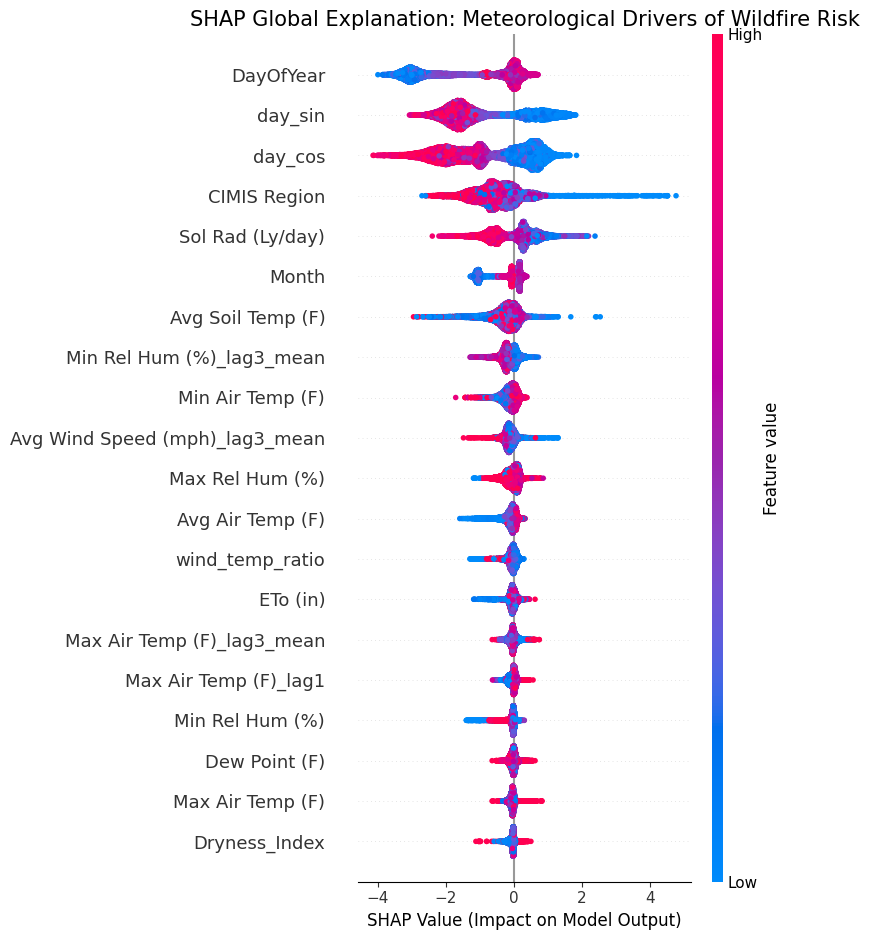

In [16]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the Explainer
# We use TreeExplainer because it is optimized for the mathematical structure of XGBoost
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)

# 3. Create the Summary (Bee Swarm) Plot
plt.figure(figsize=(10, 6))
# This plot shows feature importance + feature impact
shap.summary_plot(shap_values, X_test, show=False)

plt.title("SHAP Global Explanation: Meteorological Drivers of Wildfire Risk", fontsize=15)
plt.xlabel("SHAP Value (Impact on Model Output)", fontsize=12)
plt.tight_layout()
plt.savefig('fig1', 
            dpi=300,            # High resolution for research papers
            bbox_inches='tight', # Removes extra white space around the image
            transparent=False)
plt.show()

In [29]:
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)

# For binary classification, select class 1 (Fire)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
import numpy as np

y_probs = model_xgb.predict_proba(X_test)[:, 1]
high_risk_index = np.argmax(y_probs)


In [30]:
# Handle expected_value properly
base_value = explainer.expected_value
if isinstance(base_value, list):
    base_value = base_value[1]

local_explanation = shap.Explanation(
    values=shap_values[high_risk_index],
    base_values=base_value,
    data=X_test.iloc[high_risk_index].values,
    feature_names=X_test.columns
)


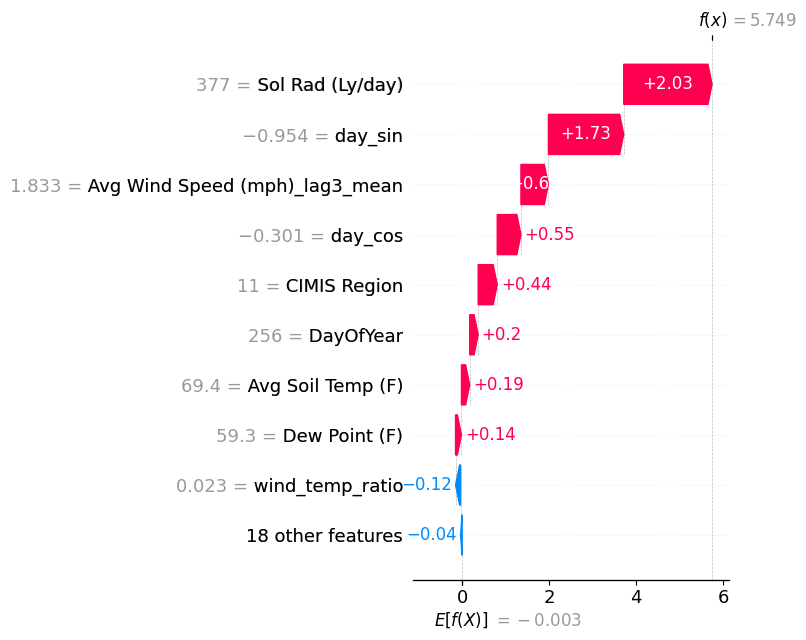

In [32]:
import matplotlib.pyplot as plt

shap.plots.waterfall(local_explanation, show=False)

fig = plt.gcf()
plt.tight_layout()

fig.savefig("Fig_Local_SHAP_Waterfall.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [19]:
import numpy as np
import lightgbm as lgb

# 1. Force the model to be less conservative
model_lgb = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,        # Faster learning to force it out of the 'zero-prediction' trap
    num_leaves=31,
    scale_pos_weight=scale_factor * 2, # Doubling the weight to force attention on fires
    random_state=42,
    verbosity=-1
)
model_lgb.fit(X_train, y_train)
# 2. Get the RAW probabilities
y_probs_lgb = model_lgb.predict_proba(X_test)[:, 1]
# 3. Diagnostic Prints
print(f"--- LightGBM Diagnostic ---")
print(f"Minimum Prob: {y_probs_lgb.min():.4f}")
print(f"Maximum Prob: {y_probs_lgb.max():.4f}")
print(f"Average Prob: {y_probs_lgb.mean():.4f}")

# 4. Find the 'Best' threshold automatically for this specific run
# We will look at the 95th percentile of predictions
suggested_threshold = np.percentile(y_probs_lgb, 95)
print(f"Suggested Threshold (95th percentile): {suggested_threshold:.4f}")

# 5. Try a report at a much lower threshold to see if it's learning ANYTHING
from sklearn.metrics import classification_report
y_pred_diagnostic = (y_probs_lgb >= 0.7).astype(int)
print("\n--- Report at 0.65 Threshold ---")
print(classification_report(y_test, y_pred_diagnostic))

--- LightGBM Diagnostic ---
Minimum Prob: 0.0000
Maximum Prob: 0.9972
Average Prob: 0.1263
Suggested Threshold (95th percentile): 0.8624

--- Report at 0.65 Threshold ---
              precision    recall  f1-score   support

           0       0.99      0.96      0.98     24554
           1       0.48      0.86      0.62      1071

    accuracy                           0.96     25625
   macro avg       0.74      0.91      0.80     25625
weighted avg       0.97      0.96      0.96     25625



LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


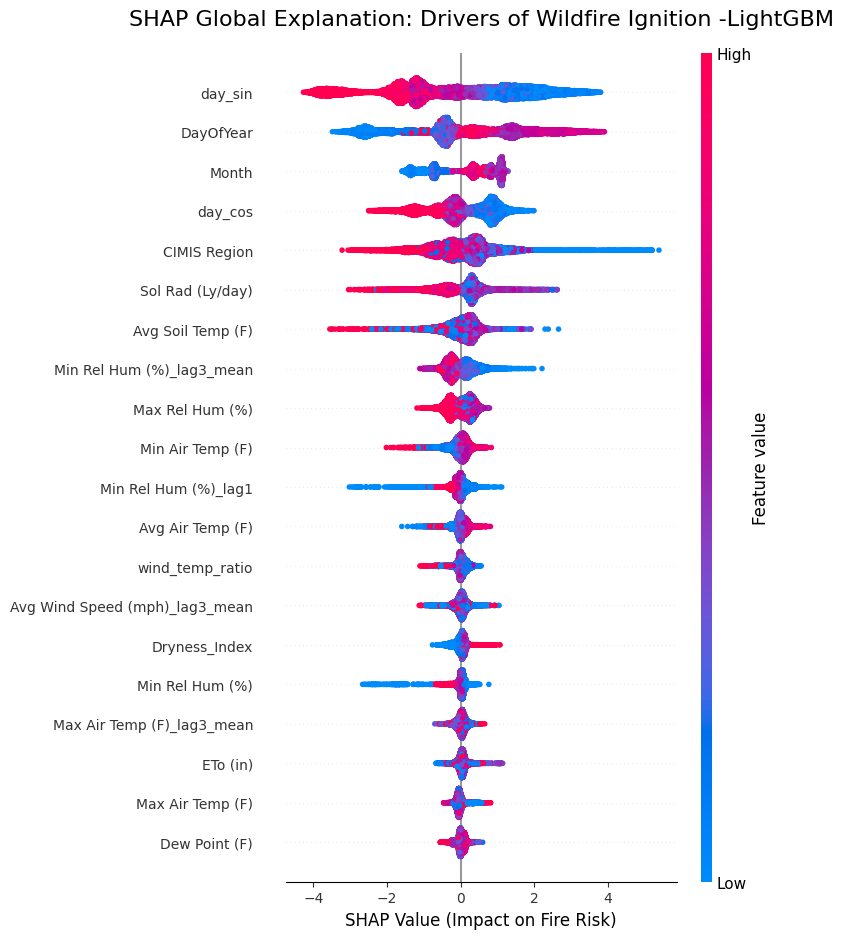

In [20]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the TreeExplainer
# TreeExplainer is specifically designed for tree-based models like LightGBM
explainer = shap.TreeExplainer(model_lgb)

# 2. Calculate SHAP values
# We use X_test to see how the model generalizes to unseen data
shap_values = explainer.shap_values(X_test)

# 3. Create the Beeswarm (Swarm) Plot
plt.figure(figsize=(12, 8))

# In binary classification, SHAP returns a list of two arrays. 
# Index 1 corresponds to the 'Fire' class.
shap.summary_plot(shap_values[1], X_test, plot_type="dot", show=False)

# 4. Final Polish for Publication
plt.title("SHAP Global Explanation: Drivers of Wildfire Ignition -LightGBM", fontsize=16, pad=20)
plt.xlabel("SHAP Value (Impact on Fire Risk)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('fig2', 
            dpi=300,            # High resolution for research papers
            bbox_inches='tight', # Removes extra white space around the image
            transparent=False)
plt.show()


In [21]:
# --------------------------------------------------------
# CatBoost Classifier for Wildfire Occurrence Prediction

from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

# 1. Initialize the CatBoost Classifier
# Note: auto_class_weights='Balanced' is an alternative to scale_pos_weight
model_cb = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.02,
    depth=6,
    scale_pos_weight=scale_factor,
    random_state=42,
    verbose=0,              # Keeps the output clean
    early_stopping_rounds=50,
    eval_metric='AUC'        # CatBoost excels at optimizing AUC
)
# 2. Fit the model
model_cb.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)
# 3. Predict Probabilities and apply your 0.65 threshold
y_probs_cb = model_cb.predict_proba(X_test)[:, 1]
y_pred_cb = (y_probs_cb >= 0.7).astype(int)

# 4. Print the Report
print("--- CatBoost Classification Report (Threshold 0.7) ---")
print(classification_report(y_test, y_pred_cb, target_names=['No Fire', 'Fire']))

--- CatBoost Classification Report (Threshold 0.7) ---
              precision    recall  f1-score   support

     No Fire       0.99      0.95      0.97     24554
        Fire       0.44      0.82      0.57      1071

    accuracy                           0.95     25625
   macro avg       0.71      0.89      0.77     25625
weighted avg       0.97      0.95      0.96     25625



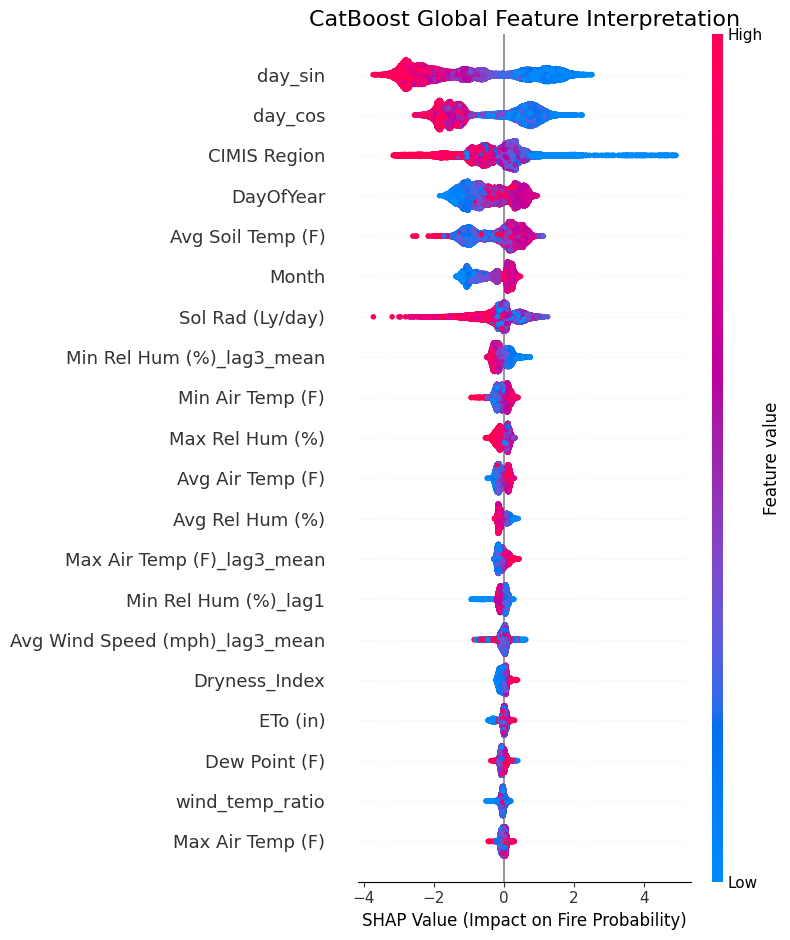

In [22]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the Explainer specifically for CatBoost
# CatBoost models have a built-in method for SHAP values
explainer_cb = shap.TreeExplainer(model_cb)

# 2. Calculate SHAP values
# Note: CatBoost SHAP values are usually returned as a simple 2D array for binary classification
shap_values_cb = explainer_cb.shap_values(X_test)

# 3. Create the Swarm (Beeswarm) Plot
plt.figure(figsize=(12, 8))

# CatBoost SHAP output typically represents the 'Fire' class directly
shap.summary_plot(shap_values_cb, X_test, plot_type="dot", show=False)

# 4. Publication Formatting
plt.title("CatBoost Global Feature Interpretation", fontsize=16)
plt.xlabel("SHAP Value (Impact on Fire Probability)", fontsize=12)
plt.tight_layout()
plt.savefig('fig3', 
            dpi=300,            # High resolution for research papers
            bbox_inches='tight', # Removes extra white space around the image
            transparent=False)
plt.show()